<img src="https://github.com/d9w/evolution/raw/master/imgs/logo.png" width="20%" align="right" style="margin:0px 20px">


# Evolutionary Algorithms

## Evolving Neural Networks with ES

<a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" align="left" src="https://i.creativecommons.org/l/by-sa/4.0/80x15.png" /></a>&nbsp;| Dennis G. Wilson, Yuri Lavinas, Paul Templier | <a href="https://d9w.github.io/evolution/">https://d9w.github.io/evolution/</a>

In order to visualize the environment in this notebook, you will need to install the following:

In [ ]:
# !apt-get install -y xvfb

In [ ]:
# !pip install cma swig

In [ ]:
# !pip install pyvirtualdisplay gymnasium[box2d]

In [ ]:
#!pip install torch

# <a name="neuroevolution">3.</a> ES for Neuroevolution

Evolutionary strategies are intended for continuous optimization and can easily be applied to the optimization of neural network parameters, or *neuroevolution*.

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.multiprocessing as mp
import numpy as np
import gymnasium as gym
import time
from tqdm.notebook import tqdm

In [ ]:
class NeuralNetwork(nn.Module):

    def __init__(self, input_shape, n_actions):
        super(NeuralNetwork, self).__init__()
        self.l1 = nn.Linear(input_shape, 32)
        self.l2 = nn.Linear(32, 32)
        self.lout = nn.Linear(32, n_actions)

    def forward(self, x):
        x = F.relu(self.l1(x.float()))
        x = F.relu(self.l2(x))
        return self.lout(x)

    def get_params(self):
        p = np.empty((0,))
        for n in self.parameters():
            p = np.append(p, n.flatten().cpu().detach().numpy())
        return p

    def set_params(self, x):
        start = 0
        for p in self.parameters():
            e = start + np.prod(p.shape)
            p.data = torch.FloatTensor(x[start:e]).reshape(p.shape)
            start = e

We'll add some visualization functionality to have the environment render directly in the notebook.

In [3]:
#from pyvirtualdisplay import Display
from IPython import display
import matplotlib.pyplot as plt
%matplotlib inline
# pydisplay = Display(visible=0, size=(1400, 900))
# pydisplay.start()
plt.ion();

Following the framework of evolutionary policy search, we will optimize a neural network representing a policy and maximize the total reward over a single episode using this policy.

In [4]:
def evaluate(ann, env, visul=True):
    obs, info = env.reset(seed=0)

    # Create the figure and axis only once before starting
    if visul:
        plt.figure(figsize=(8, 6))
        img = plt.imshow(env.render())
        plt.axis('off')
        plt.tight_layout()

    total_reward = 0
    while True:
        # Output of the neural net
        net_output = ann(torch.tensor(obs))
        # the action is the value clipped returned by the nn
        action = net_output.data.cpu().numpy().argmax()
        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward

        if visul:
            img.set_data(env.render())
            display.display(plt.gcf())
            display.clear_output(wait=True)
            # Small sleep to allow rendering to complete properly
            time.sleep(0.01)

        if done:
            break

    if visul:
        plt.close()

    return total_reward

In [5]:
import base64
def evaluate_video(ann, env, visul=True):
    obs, info = env.reset(seed=0)
    total_reward = 0

    if visul:
        frames = []
        frames.append(env.render())

    while True:
        net_output = ann(torch.tensor(obs))
        action = net_output.data.cpu().numpy().argmax()
        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward

        if visul:
            frames.append(env.render())

        if done:
            break

    if visul:
        # Convert frames to mp4 video
        from moviepy.editor import ImageSequenceClip
        from IPython.display import HTML

        clip = ImageSequenceClip(frames, fps=20)
        video_file = 'lunar_lander.mp4'
        clip.write_videofile(video_file, fps=20)

        # Display the video
        with open(video_file, 'rb') as f:
            video_data = f.read()

        display.display(HTML("""
        <video width="640" height="480" controls autoplay>
            <source src="data:video/mp4;base64,{0}" type="video/mp4">
        </video>
        """.format(base64.b64encode(video_data).decode())))

    return total_reward

We've configured this for discrete action spaces. We can see a random neural network on different environments like `CartPole-v0`, `MountainCar-v0`, and `LunarLander-v2`.

In [8]:
env = gym.make('LunarLander-v3', render_mode='rgb_array')
ann = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)

c:\Users\vache\miniconda3\envs\research\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [11]:
evaluate_video(ann, env, visul=True)

Moviepy - Building video lunar_lander.mp4.
Moviepy - Writing video lunar_lander.mp4



Moviepy - Done !
Moviepy - video ready lunar_lander.mp4


np.float64(-350.81531664818067)

In order to evolve the parameters of this neural network, we will modify the parameters of the network using `set_params` with the genes of the new individual. In the evolutionary literature, this is referred to as a *direct encoding* as the neural network parameters are directly encoded in the genome.

In [12]:
def fitness(x, ann, env, visul=False):
    ann.set_params(x)
    return -evaluate(ann, env, visul=visul)

In [13]:
p = ann.get_params()
np.shape(p)

(1476,)

We can first observe a random individual $x$.

In [16]:
x = np.random.rand(len(p))
-fitness(x, ann, env, visul=True)

np.float64(-412.39050294751365)

Let's try optimizing the policy using the simple $(\mu, \lambda)$ ES we proposed.

In [24]:
def mu_lambda(x, fitness, gens=200, lam=10, alpha=0.2, verbose=False):
    x_best = x
    f_best = fitness(x)
    fits = np.zeros(gens)
    for g in tqdm(range(gens)):
        N = np.random.normal(size=(lam, len(x)))
        F = np.zeros(lam)
        for i in range(lam):
            ind = x + N[i, :]
            F[i] = fitness(ind)
            if F[i] < f_best:
                f_best = F[i]
                x_best = ind
                if verbose:
                    print(g, " ", f_best)
        fits[g] = f_best
        mu_f = np.mean(F)
        std_f = np.std(F)
        A = F
        if std_f != 0:
            A = (F - mu_f) / std_f
        x = x - alpha * np.dot(A, N) / lam
    return fits, x_best

In [25]:
np.random.seed(654)
env = gym.make('LunarLander-v3', render_mode='rgb_array')
ann = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)
x = np.random.randn(len(ann.get_params()))
f = lambda x : fitness(x, ann, env)
fits, x = mu_lambda(x, f, gens=100, lam=20, alpha=0.1, verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

0   100.71089161555129
1   -66.9440680764344


In [26]:
fits

array([100.71089162, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94406808,
       -66.94406808, -66.94406808, -66.94406808, -66.94

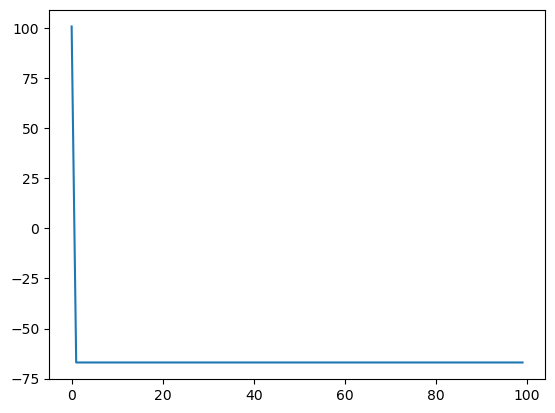

In [27]:
plt.plot(fits);

In [28]:
-fitness(x, ann, env, visul=True)

np.float64(66.9440680764344)

# CMA-ES for Neuroevolution

We will now use CMA-ES for the Lunar Lander problem

In [29]:
import cma
np.random.seed(123)
env = gym.make('LunarLander-v3', render_mode='rgb_array')
ann = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)
es = cma.CMAEvolutionStrategy(len(ann.get_params()) * [0], 0.1, {'seed': 123})

(12_w,25)-aCMA-ES (mu_w=7.3,w_1=23%) in dimension 1476 (seed=123, Sat Mar  7 14:42:15 2026)


In [30]:
for i in range(20):
    solutions = np.array(es.ask())
    fits = [fitness(x, ann, env) for x in solutions]
    es.tell(solutions, fits)
    es.disp()

Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     25 -2.200048756713315e+00 1.0e+00 9.95e-02  1e-01  1e-01 0:00.7
    2     50 9.724466236668879e+01 1.0e+00 9.89e-02  1e-01  1e-01 0:01.4
    3     75 1.190597264852492e+02 1.0e+00 9.84e-02  1e-01  1e-01 0:01.9
   10    250 9.872070569910836e+01 1.0e+00 9.54e-02  1e-01  1e-01 0:05.3
   16    400 -7.574558913098616e+01 1.0e+00 9.34e-02  9e-02  9e-02 0:09.4


In [32]:
x = es.result[0]
-fitness(x, ann, env, visul=True)

np.float64(75.74558913098616)

The results on LunarLander clearly show the benefits of CMA-ES; we have found a reasonable policy in a small number of generations. Applying CMA-ES to larger neural networks remains an open challenge, however, due to the vast number of parameters in ANNs. Specifically, CMA-ES calculates the covariance of all parameters, which is $O(n^2)$.

In [33]:
np.shape(es.sm.C)

(1476, 1476)

<div class="alert alert-success">
    <h3>Exercise 1</h3>
    
The network used has 2 layers of 32 neurons each. Try changing this and noticing the impact on the number of total parameters for CMA-ES. How large of a network can CMA-ES optimize?
</div>

In [46]:
n = 64 

class NeuralNetworkTest(nn.Module):

    def __init__(self, input_shape, n_actions):
        super(NeuralNetworkTest, self).__init__()
        self.l1 = nn.Linear(input_shape, n)
        self.l2 = nn.Linear(n, n)
        self.lout = nn.Linear(n, n_actions)

    def forward(self, x):
        x = F.relu(self.l1(x.float()))
        x = F.relu(self.l2(x))
        return self.lout(x)

    def get_params(self):
        p = np.empty((0,))
        for n in self.parameters():
            p = np.append(p, n.flatten().cpu().detach().numpy())
        return p

    def set_params(self, x):
        start = 0
        for p in self.parameters():
            e = start + np.prod(p.shape)
            p.data = torch.FloatTensor(x[start:e]).reshape(p.shape)
            start = e

In [40]:
np.random.seed(123)
ann = NeuralNetworkTest(env.observation_space.shape[0], env.action_space.n)
env = gym.make('LunarLander-v3', render_mode='rgb_array')
es = cma.CMAEvolutionStrategy(len(ann.get_params()) * [0], 0.1, {'seed': 123})

(16_w,33)-aCMA-ES (mu_w=9.4,w_1=19%) in dimension 18180 (seed=123, Sat Mar  7 15:00:46 2026)


In [41]:
for i in range(20):
    solutions = np.array(es.ask())
    fits = [fitness(x, ann, env) for x in solutions]
    es.tell(solutions, fits)
    es.disp()

Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     33 9.920961051157329e+01 1.0e+00 9.99e-02  1e-01  1e-01 0:09.4
    2     66 -1.345821632637600e+01 1.0e+00 9.99e-02  1e-01  1e-01 0:15.3
    3     99 9.773810605767436e+01 1.0e+00 9.98e-02  1e-01  1e-01 0:20.7
    4    132 1.115481932203176e+02 1.0e+00 9.98e-02  1e-01  1e-01 0:26.7
    5    165 1.124889399532655e+02 1.0e+00 9.97e-02  1e-01  1e-01 0:33.1
    6    198 9.872070569910836e+01 1.0e+00 9.96e-02  1e-01  1e-01 0:39.0
    7    231 1.001174453266731e+02 1.0e+00 9.96e-02  1e-01  1e-01 0:45.0
    9    297 6.976191325999544e+01 1.0e+00 9.95e-02  1e-01  1e-01 0:55.4
   11    363 -4.558900058913974e+01 1.0e+00 9.94e-02  1e-01  1e-01 1:05.5
   13    429 -4.558900058913974e+01 1.0e+00 9.93e-02  1e-01  1e-01 1:15.4
   15    495 7.511815450852099e+01 1.0e+00 9.92e-02  1e-01  1e-01 1:25.5
   18    594 4.753541167084610e+01 1.0e+00 9.90e-02  1e-01  1e-01 1:40.5


In [42]:
x = es.result[0]
-fitness(x, ann, env, visul=True)

np.float64(67.0953201519041)

In [43]:
np.shape(es.sm.C)

(18180, 18180)

<div class="alert alert-success">
    <h3>Exercise 2</h3>
    
Compare the $(1+\lambda)$ ES, $(\mu,\lambda)$ ES, and CMA-ES algorithms on Lunar Lander. Is one significantly better than the others, consistently across different initializations?
</div>

In [47]:
def oneplus_lambda(x, fitness, gens=100, lam=20):
    x_best = x
    f_best = fitness(x)
    fits = np.zeros(gens)
    for g in range(gens):
        N = np.random.normal(size=(lam, len(x)))
        for i in range(lam):
            ind = x + N[i, :]
            f = fitness(ind)
            if f < f_best:
                f_best = f
                x_best = ind
        x = x_best
        fits[g] = f_best
    return fits, x

def mu_lambda(x, fitness, gens=200, lam=10, alpha=0.2, verbose=False):
    x_best = x
    f_best = fitness(x)
    fits = np.zeros(gens)
    for g in tqdm(range(gens)):
        N = np.random.normal(size=(lam, len(x)))
        F = np.zeros(lam)
        for i in range(lam):
            ind = x + N[i, :]
            F[i] = fitness(ind)
            if F[i] < f_best:
                f_best = F[i]
                x_best = ind
                if verbose:
                    print(g, " ", f_best)
        fits[g] = f_best
        mu_f = np.mean(F)
        std_f = np.std(F)
        A = F
        if std_f != 0:
            A = (F - mu_f) / std_f
        x = x - alpha * np.dot(A, N) / lam
    return fits, x_best

In [60]:
np.random.seed(123)
ann = NeuralNetworkTest(env.observation_space.shape[0], env.action_space.n)
env = gym.make('LunarLander-v3', render_mode='rgb_array')
es = cma.CMAEvolutionStrategy(len(ann.get_params()) * [0], 0.1, {'seed': 123})

for i in range(50):
    solutions = np.array(es.ask())
    fits = [fitness(x, ann, env) for x in solutions]
    es.tell(solutions, fits)
    es.disp()

x = es.result[0]


np.shape(es.sm.C)

(14_w,29)-aCMA-ES (mu_w=8.4,w_1=21%) in dimension 4996 (seed=123, Sat Mar  7 20:12:37 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     29 2.176628610675168e+01 1.0e+00 9.98e-02  1e-01  1e-01 0:01.2
    2     58 1.135932315788519e+02 1.0e+00 9.96e-02  1e-01  1e-01 0:02.1
    3     87 6.439815940140643e+01 1.0e+00 9.94e-02  1e-01  1e-01 0:03.3
    7    203 6.925607769204200e+01 1.0e+00 9.87e-02  1e-01  1e-01 0:06.7
   12    348 5.359997056993923e+01 1.0e+00 9.79e-02  1e-01  1e-01 0:11.6
   17    493 1.844605570397370e+01 1.0e+00 9.72e-02  1e-01  1e-01 0:16.8
   23    667 1.408979410539274e+01 1.0e+00 9.63e-02  1e-01  1e-01 0:23.4
   30    870 -4.142358770313948e+01 1.0e+00 9.54e-02  1e-01  1e-01 0:30.6
   34    986 -6.709532015190410e+01 1.0e+00 9.49e-02  9e-02  9e-02 0:50.8
   43   1247 -2.413522961980571e+01 1.0e+00 9.38e-02  9e-02  9e-02 1:00.1


(4996, 4996)

In [61]:
-fitness(x, ann, env, visul=True)

np.float64(85.60468618372016)

In [ ]:
np.random.seed(654)
env = gym.make('LunarLander-v3', render_mode='rgb_array')
ann = NeuralNetwork(env.observation_space.shape[0], env.action_space.n)
x = np.random.randn(len(ann.get_params()))
f = lambda x : fitness(x, ann, env)
fits, x = oneplus_lambda(x, f, gens = 100, lam = 20, alpha =)

TypeError: oneplus_lambda() got an unexpected keyword argument 'alpha'

In [52]:
-fitness(x, ann, env, visul=True)

np.float64(288.9614425765684)

In [56]:
x = np.random.randn(len(ann.get_params()))
f = lambda x : fitness(x, ann, env)
fits, x = mu_lambda(x, f, gens = 100, lam = 20, alpha = 0.2)

  0%|          | 0/100 [00:00<?, ?it/s]

In [57]:
-fitness(x, ann, env, visul=True)

np.float64(67.0953201519041)